# Projeto de Análise: Percepção de Desigualdade (IPEC) vs. Dados Oficiais (IBGE)

Este notebook segue o roteiro definido:
1. **EDA da Base IPEC:** Carregamento, limpeza e visualizações das percepções.
2. **Relação com IBGE:** Cruzamento com dados populacionais oficiais via API.

In [92]:
# Instalação de pacotes necessários para ler arquivos .sav (SPSS)
!pip install pyreadstat plotly seaborn requests -q

In [93]:
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")

## 1. Leitura e Preparação dos Dados
Lendo o arquivo `.sav` e aplicando o dicionário de dados.

In [94]:
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy.stats import chi2_contingency

# 1. Carregamento dos Dados
file_url = 'https://github.com/ciencia-dados-2026-01-romeo/parte-a/raw/refs/heads/main/04839.sav'
local_file = '04839.sav'

if not pd.io.common.file_exists(local_file):
    response = requests.get(file_url)
    with open(local_file, 'wb') as f:
        f.write(response.content)

df, meta = pyreadstat.read_sav(local_file)

# Mapeamentos para EDA
df['SEXO_MAP'] = df['SEXO'].map({1.0: 'Masculino', 2.0: 'Feminino'})
df['REGIAO_MAP'] = df['REGIAO'].map({1.0: 'Norte', 2.0: 'Nordeste', 3.0: 'Sudeste', 4.0: 'Sul', 5.0: 'Centro-Oeste'})
df['RACA_MAP'] = df['RACA_COR'].map({1.0: 'Branca', 2.0: 'Preta', 3.0: 'Parda', 4.0: 'Amarela', 5.0: 'Indígena', 9.0: 'Não sabe'})

# Reintroduzindo o mapeamento de escolaridade para o teste Qui-Quadrado
def categoriza_escolaridade(val):
    if val <= 3: return 'Fundamental I / Sem instrução'
    elif val <= 5: return 'Fundamental II'
    elif val <= 7: return 'Ensino Médio'
    else: return 'Ensino Superior'

df['ESCOLARIDADE_MAP'] = df['ESCOLARIDADE'].apply(categoriza_escolaridade)

print(f"Base IPEC carregada com {len(df)} registros.")
display(df[['SEXO_MAP', 'REGIAO_MAP', 'ESCOLARIDADE_MAP']].head())

Base IPEC carregada com 2000 registros.


,SEXO_MAP,REGIAO_MAP,ESCOLARIDADE_MAP
0,Feminino,Centro-Oeste,Ensino Superior
1,Feminino,Centro-Oeste,Ensino Superior
2,Masculino,Centro-Oeste,Ensino Superior
3,Masculino,Centro-Oeste,Fundamental I / Sem instrução
4,Feminino,Sudeste,Fundamental II


## 2. Análise Exploratória (EDA)
Visualizando a distribuição das opiniões sobre onde há mais diferença no tratamento (Variável P1_1).

/tmp/ipykernel_5204/997162822.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RACA_MAP', ax=ax2, palette='magma')


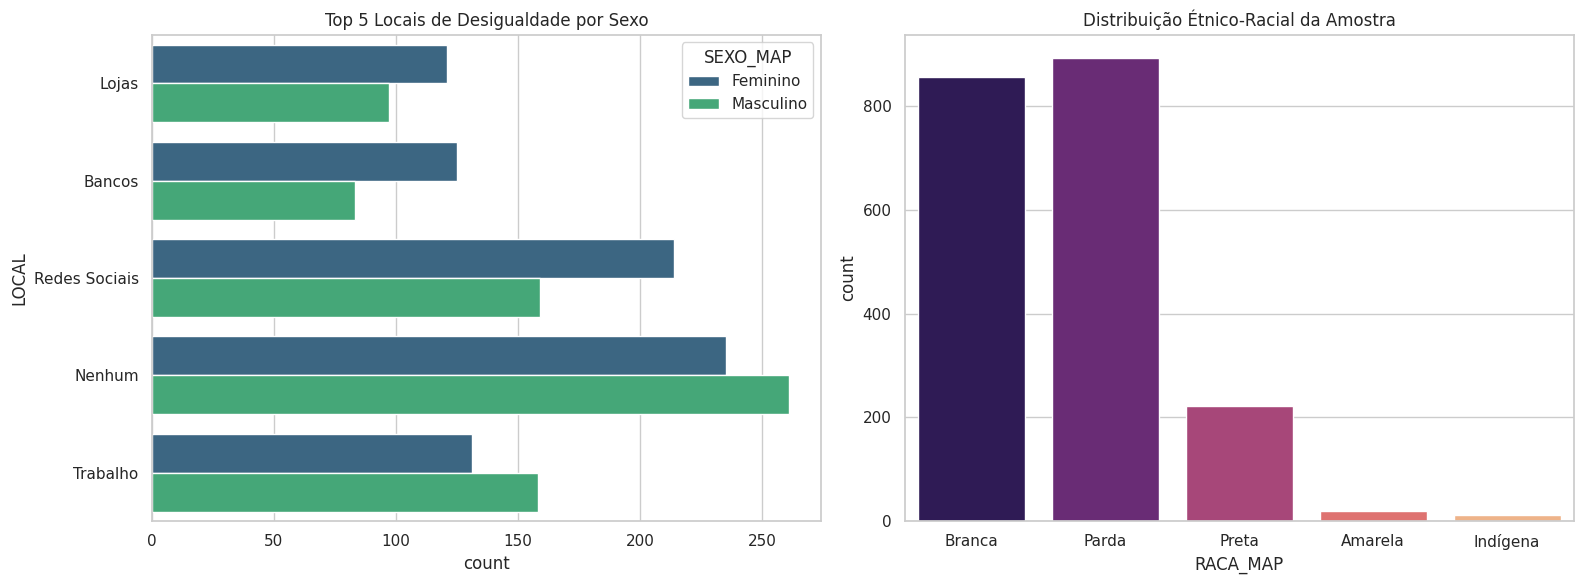

In [95]:
# 2. Análise Gráfica da Base IPEC
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Onde a desigualdade é mais sentida (P1_1)
mapping_p1 = {1.0: 'Trabalho', 2.0: 'Lojas', 3.0: 'Bancos', 7.0: 'Redes Sociais', 97.0: 'Nenhum'}
top_5 = df['P1_1'].value_counts().nlargest(5).index
df_plot = df[df['P1_1'].isin(top_5)].copy()
df_plot['LOCAL'] = df_plot['P1_1'].map(mapping_p1)

sns.countplot(data=df_plot, y='LOCAL', hue='SEXO_MAP', ax=ax1, palette='viridis')
ax1.set_title('Top 5 Locais de Desigualdade por Sexo')

# Gráfico 2: Distribuição por Raça/Cor
sns.countplot(data=df, x='RACA_MAP', ax=ax2, palette='magma')
ax2.set_title('Distribuição Étnico-Racial da Amostra')

plt.tight_layout()
plt.show()

In [96]:
import pandas as pd

# Mapeando apenas os códigos que aparecem no gráfico (Top 5)
p1_1_mapping_subset = {
    1.0: "No trabalho / No processo de seleção",
    2.0: "Em lojas / Shoppings",
    3.0: "Em bancos / Instituições financeiras",
    7.0: "Em redes sociais / Internet",
    97.0: "Não costuma frequentar esses locais / Nenhum desses"
}

print("Legenda para os códigos apresentados no gráfico:")
legend_df = pd.Series(p1_1_mapping_subset).to_frame(name='Descrição')
display(legend_df)

Legenda para os códigos apresentados no gráfico:


,Descrição
1.0,No trabalho / No processo de seleção
2.0,Em lojas / Shoppings
3.0,Em bancos / Instituições financeiras
7.0,Em redes sociais / Internet
97.0,Não costuma frequentar esses locais / Nenhum d...


## 3. Correlação com Base Pública (API do IBGE)
Comparando a distribuição demográfica da amostra da pesquisa com os dados oficiais de projeção populacional do IBGE (SIDRA).

Buscando dados oficiais do IBGE para validação da amostra...


,Sexo,IBGE (%),Amostra IPEC (%)
0,Masculino,48.966789,48.25
1,Feminino,51.033211,51.75


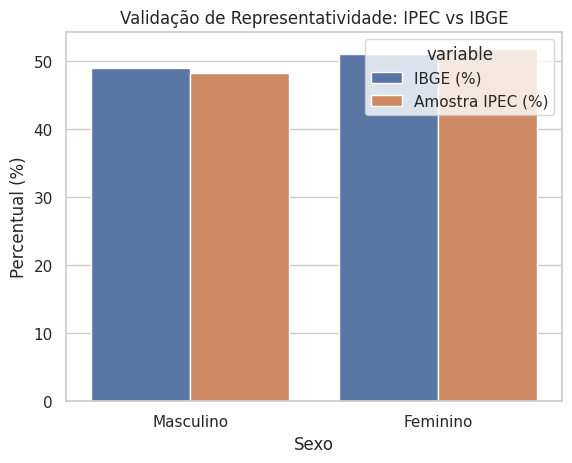

In [97]:
# 3. Integração e Relação com Base do IBGE
print("Buscando dados oficiais do IBGE para validação da amostra...")
url_ibge = "https://servicodados.ibge.gov.br/api/v3/agregados/1378/periodos/2010/variaveis/93?localidades=N1[all]&classificacao=2[4,5]"
resp = requests.get(url_ibge).json()

homens_ibge = int(resp[0]['resultados'][0]['series'][0]['serie']['2010'])
mulheres_ibge = int(resp[0]['resultados'][1]['series'][0]['serie']['2010'])
total = homens_ibge + mulheres_ibge

# Comparando Proporções
comp = pd.DataFrame({
    'Sexo': ['Masculino', 'Feminino'],
    'IBGE (%)': [(homens_ibge/total)*100, (mulheres_ibge/total)*100],
    'Amostra IPEC (%)': [df['SEXO_MAP'].value_counts(normalize=True)['Masculino']*100,
                         df['SEXO_MAP'].value_counts(normalize=True)['Feminino']*100]
})

display(comp)

# Gráfico de Correlação Amostra vs População
comp.melt(id_vars='Sexo').pipe((sns.barplot, 'data'), x='Sexo', y='value', hue='variable')
plt.title('Validação de Representatividade: IPEC vs IBGE')
plt.ylabel('Percentual (%)')
plt.show()

In [98]:
import pandas as pd

# Processando dados do IBGE (Projeção 2010 para fins de exemplo didático)
# Estrutura: Masculino (código 4), Feminino (código 5)
ibge_series = dados_ibge[0]['resultados']

homens_ibge = int(ibge_series[0]['series'][0]['serie']['2010'])
mulheres_ibge = int(ibge_series[1]['series'][0]['serie']['2010'])
total_ibge = homens_ibge + mulheres_ibge

# Proporções IBGE
prop_h_ibge = (homens_ibge / total_ibge) * 100
prop_m_ibge = (mulheres_ibge / total_ibge) * 100

# Proporções na Amostra IPEC (df)
prop_amostra = df['SEXO_MAP'].value_counts(normalize=True) * 100

# Criando DataFrame comparativo
comparativo = pd.DataFrame({
    'Fonte': ['IBGE (Oficial)', 'IBGE (Oficial)', 'IPEC (Amostra)', 'IPEC (Amostra)'],
    'Sexo': ['Masculino', 'Feminino', 'Masculino', 'Feminino'],
    'Porcentagem': [prop_h_ibge, prop_m_ibge, prop_amostra.get('Masculino', 0), prop_amostra.get('Feminino', 0)]
})

display(comparativo)

,Fonte,Sexo,Porcentagem
0,IBGE (Oficial),Masculino,48.966789
1,IBGE (Oficial),Feminino,51.033211
2,IPEC (Amostra),Masculino,48.250000
3,IPEC (Amostra),Feminino,51.750000


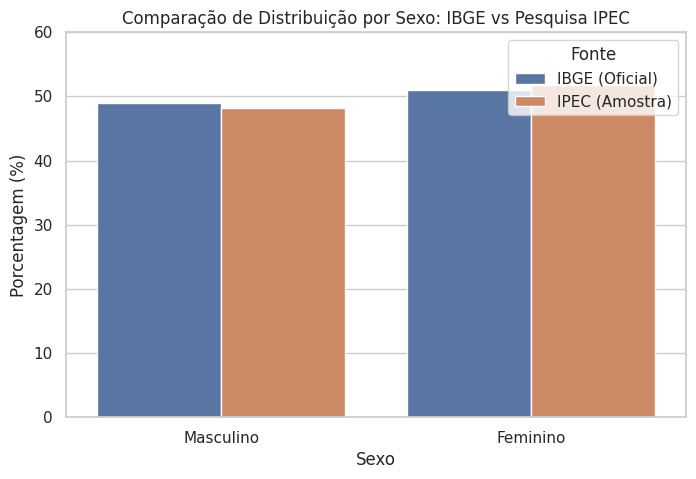

A amostra da pesquisa apresenta 51.7% de mulheres, enquanto o dado oficial aponta 51.0%.


In [99]:
# Visualização da Correlação: Amostra vs Dado Público
plt.figure(figsize=(8, 5))
sns.barplot(data=comparativo, x='Sexo', y='Porcentagem', hue='Fonte')
plt.title('Comparação de Distribuição por Sexo: IBGE vs Pesquisa IPEC')
plt.ylabel('Porcentagem (%)')
plt.ylim(0, 60)
plt.show()

print(f"A amostra da pesquisa apresenta {prop_amostra.get('Feminino', 0):.1f}% de mulheres, enquanto o dado oficial aponta {prop_m_ibge:.1f}%.")

## 4. Testes Estatísticos (Rubrica 3.3)
Utilizando Qui-Quadrado para verificar se há independência estatística entre a Escolaridade e a percepção de desigualdade.

In [100]:
# 4. Teste de Hipótese: Escolaridade vs Percepção de Local
# Removendo valores 'Não sabe/Não respondeu' da P1_1 para o teste (99.0)
df_filtered = df[df['P1_1'] <= 97.0]

tabela_cont = pd.crosstab(df_filtered['ESCOLARIDADE_MAP'], df_filtered['P1_1'])

chi2, p_valor, dof, esperado = chi2_contingency(tabela_cont)

print(f"Teste Qui-Quadrado de Independência:\nEstatística Chi2: {chi2:.2f}\nValor-p: {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusão: Rejeita-se a hipótese nula. Há uma associação significativa entre escolaridade e a percepção de desigualdade.")
else:
    print("Conclusão: Não há evidência estatística de associação entre as variáveis.")

Teste Qui-Quadrado de Independência:
Estatística Chi2: 100.95
Valor-p: 2.0716e-11
Conclusão: Rejeita-se a hipótese nula. Há uma associação significativa entre escolaridade e a percepção de desigualdade.


### Análise Adicional: Percepção de Desigualdade por Renda Familiar
Vamos verificar como os diferentes estratos de renda percebem os locais onde a desigualdade é mais latente.

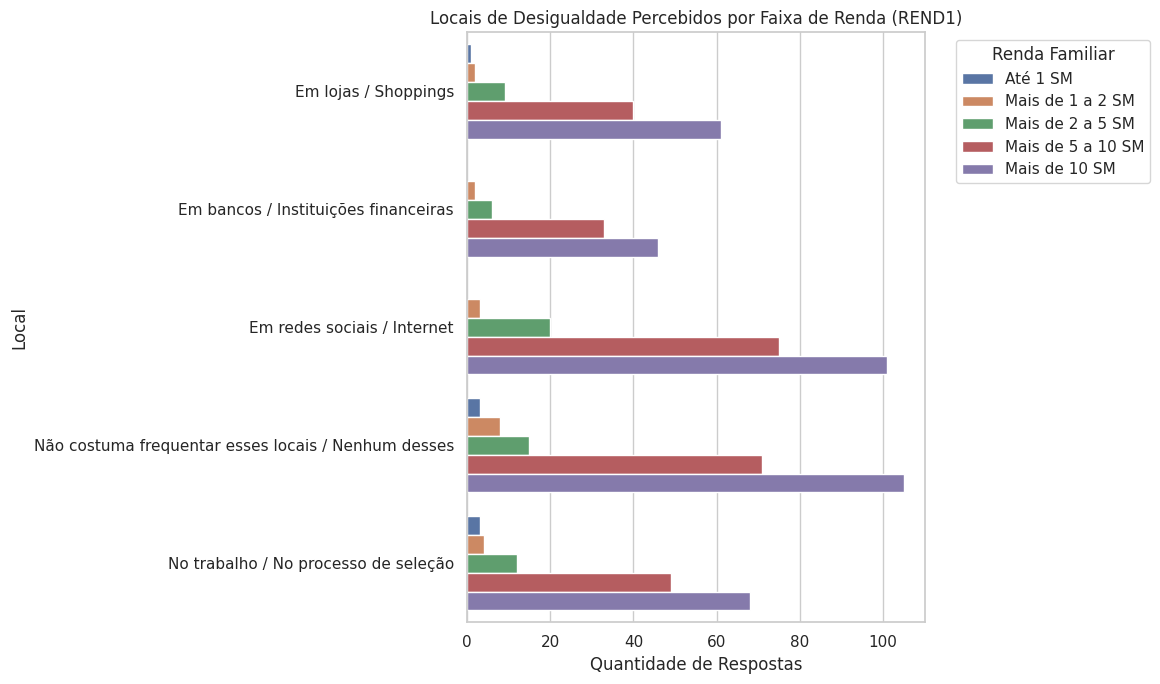

In [101]:
# Mapeando a variável de Renda Familiar (REND1)
# Ajustado conforme os códigos comuns em pesquisas IPEC/IBOPE
mapping_renda = {
    1.0: 'Até 1 SM',
    2.0: 'Mais de 1 a 2 SM',
    3.0: 'Mais de 2 a 5 SM',
    4.0: 'Mais de 5 a 10 SM',
    5.0: 'Mais de 10 SM',
    9.0: 'Não sabe / Recusou'
}

if 'REND1' in df.columns:
    df['RENDA_MAP'] = df['REND1'].map(mapping_renda)

    # Filtrando apenas os locais do Top 5
    top_5_ids = [1.0, 2.0, 3.0, 7.0, 97.0]
    df_renda_analise = df[df['P1_1'].isin(top_5_ids)].copy()
    df_renda_analise['LOCAL_DESC'] = df_renda_analise['P1_1'].map(p1_1_mapping_subset)

    plt.figure(figsize=(12, 7))
    sns.countplot(data=df_renda_analise, y='LOCAL_DESC', hue='RENDA_MAP',
                  hue_order=['Até 1 SM', 'Mais de 1 a 2 SM', 'Mais de 2 a 5 SM', 'Mais de 5 a 10 SM', 'Mais de 10 SM'])
    plt.title('Locais de Desigualdade Percebidos por Faixa de Renda (REND1)')
    plt.xlabel('Quantidade de Respostas')
    plt.ylabel('Local')
    plt.legend(title='Renda Familiar', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Variável REND1 não encontrada.")

### 6. Exploração Geral de Todas as Variáveis
Para avaliar a base completa, vamos gerar gráficos de distribuição para as variáveis de percepção (P1 a P6) e características sociodemográficas adicionais.

/tmp/ipykernel_5204/2052420382.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=var, ax=axes[i], palette='magma', order=df[var].value_counts().index)
/tmp/ipykernel_5204/2052420382.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=var, ax=axes[i], palette='magma', order=df[var].value_counts().index)
/tmp/ipykernel_5204/2052420382.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=var, ax=axes[i], palette='magma', order=df[var].value_counts().index)
/tmp/ipykernel_5204/2052420382.py:17: FutureWa

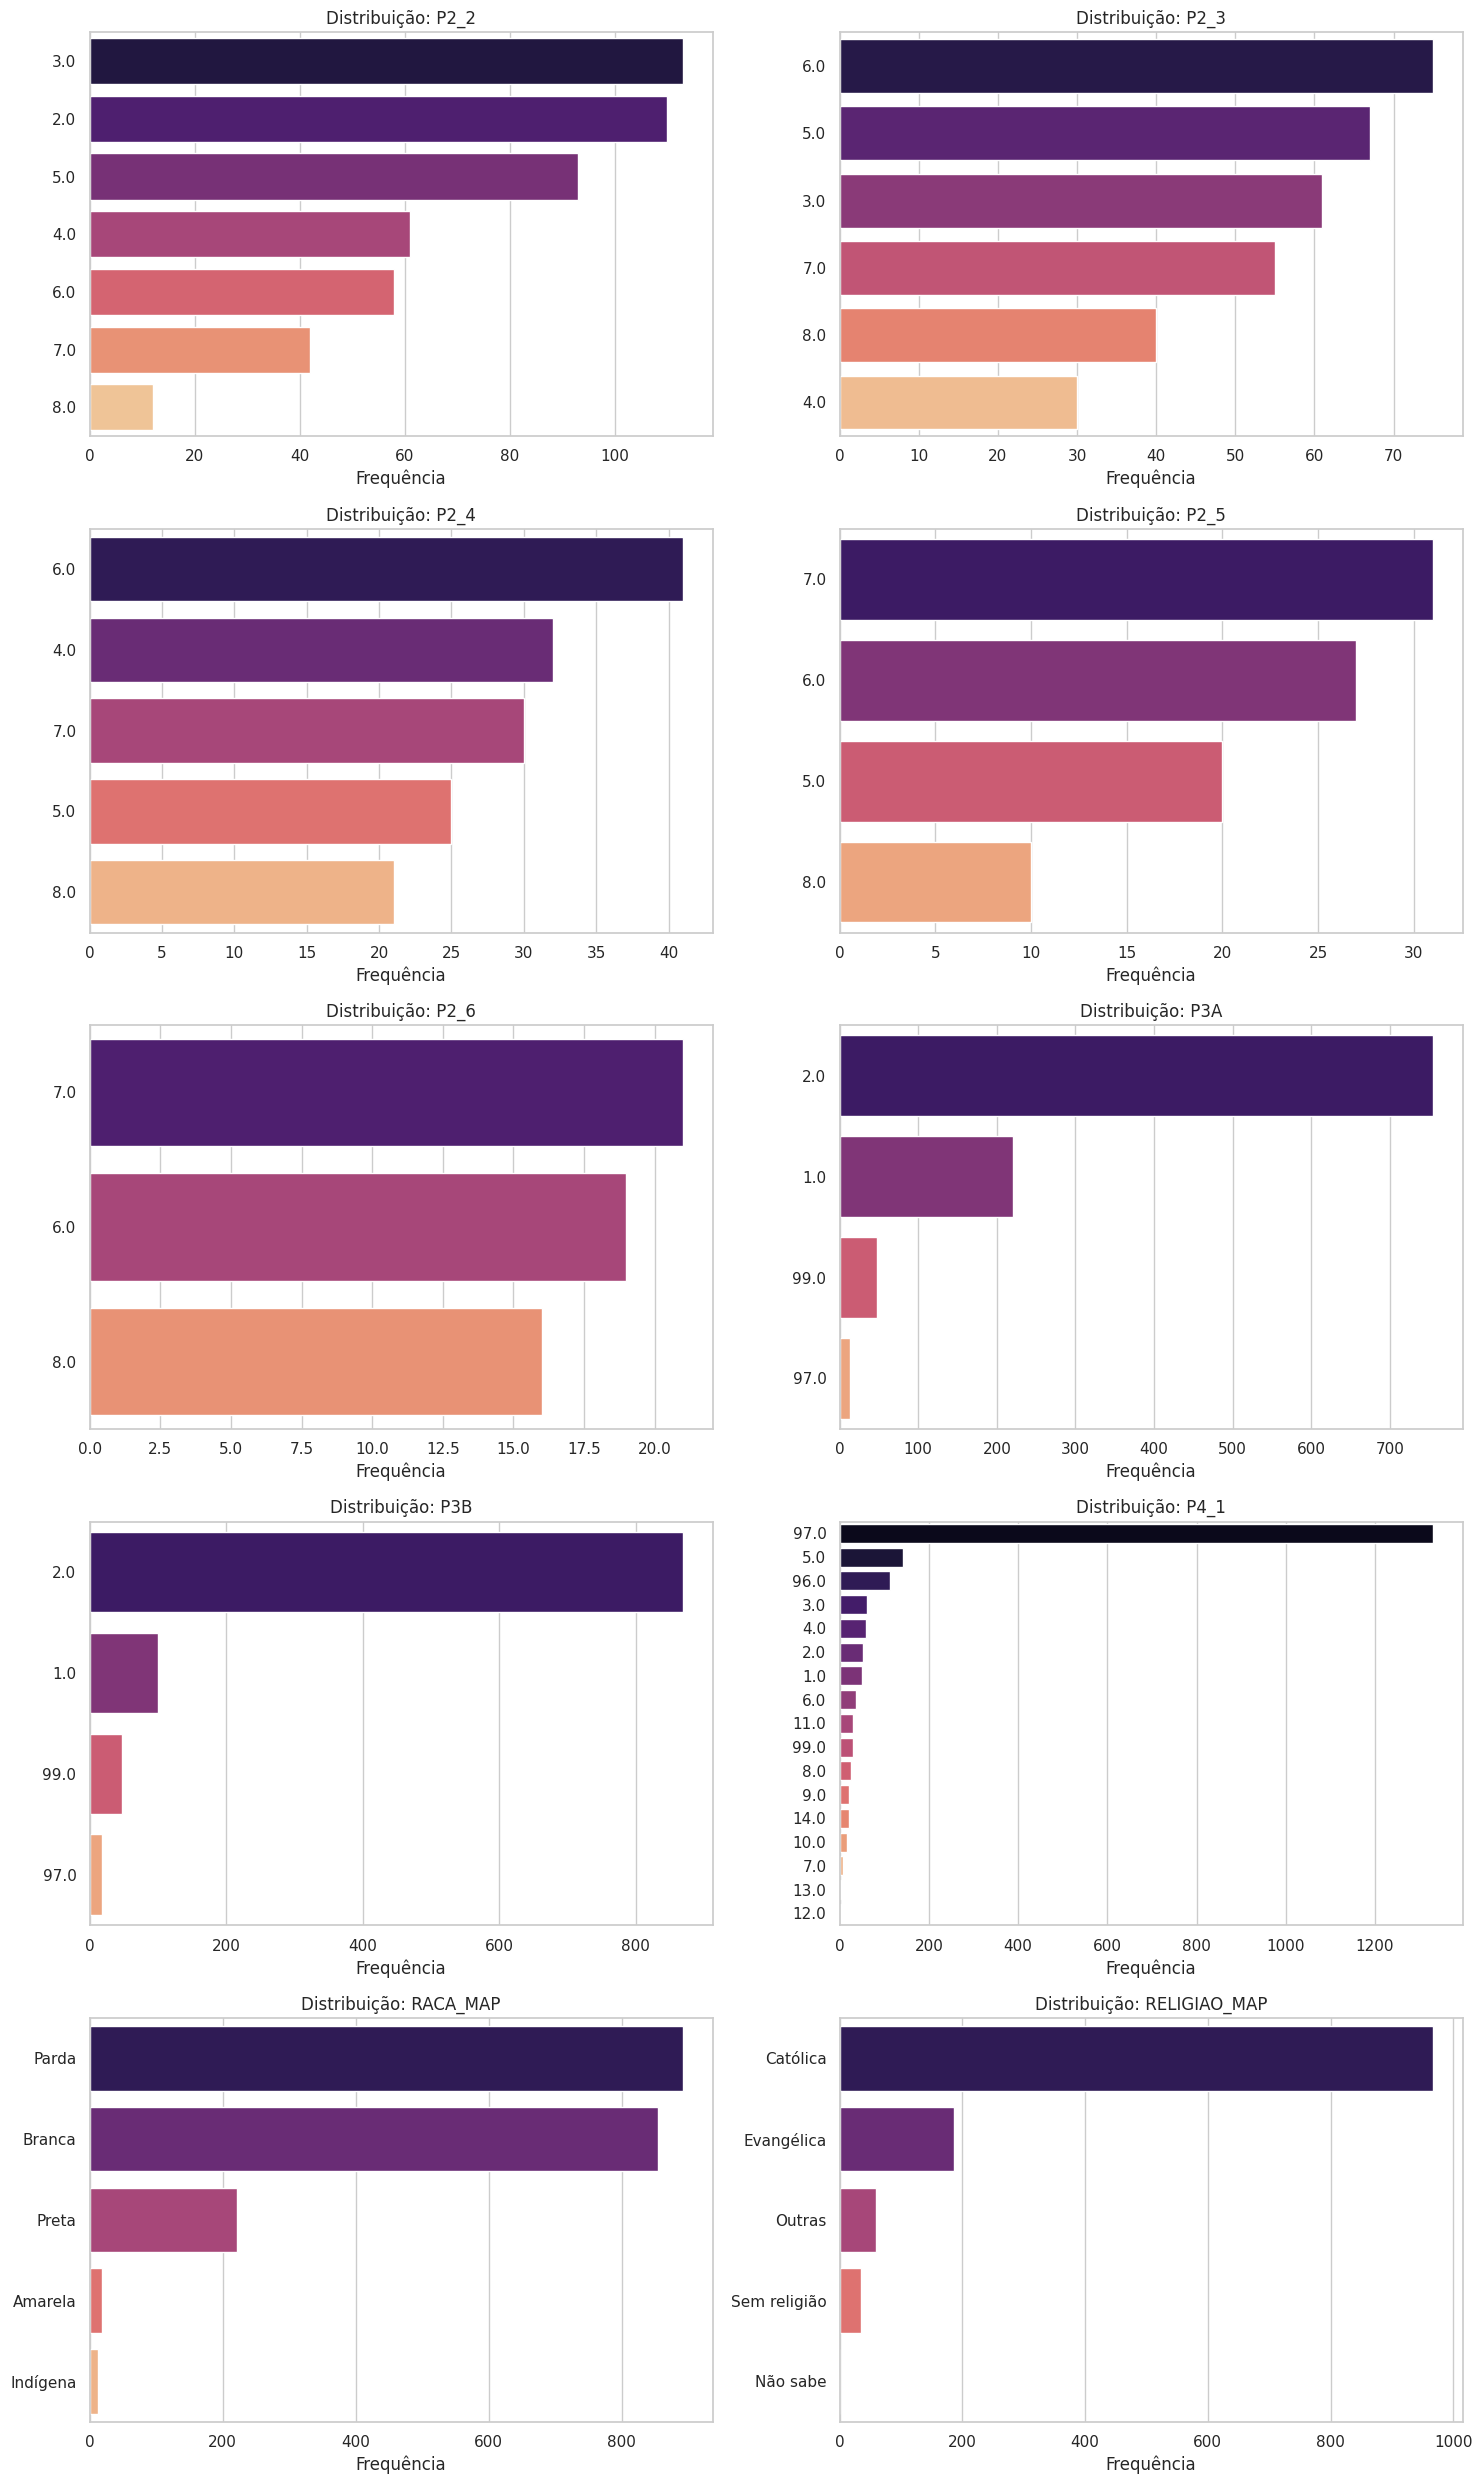

In [102]:
# Mapeando variáveis demográficas adicionais
mapping_raca = {1.0: 'Branca', 2.0: 'Preta', 3.0: 'Parda', 4.0: 'Amarela', 5.0: 'Indígena', 9.0: 'Não sabe'}
mapping_religiao = {1.0: 'Católica', 2.0: 'Evangélica', 3.0: 'Outras', 4.0: 'Sem religião', 9.0: 'Não sabe'}

df['RACA_MAP'] = df['RACA_COR'].map(mapping_raca)
df['RELIGIAO_MAP'] = df['RELIGIÃO'].map(mapping_religiao)

# Lista de variáveis de interesse para visualização em lote
vars_percepcao = ['P2_2', 'P2_3', 'P2_4', 'P2_5', 'P2_6', 'P3A', 'P3B', 'P4_1', 'RACA_MAP', 'RELIGIAO_MAP']

# Criando uma grade de gráficos
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
axes = axes.flatten()

for i, var in enumerate(vars_percepcao):
    if var in df.columns:
        sns.countplot(data=df, y=var, ax=axes[i], palette='magma', order=df[var].value_counts().index)
        axes[i].set_title(f'Distribuição: {var}')
        axes[i].set_xlabel('Frequência')
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### 7. Matriz de Correlação entre Variáveis de Percepção
Vamos converter as respostas de percepção (onde 1=Sim/Muito e 2=Não/Pouco) para observar como as opiniões se agrupam.

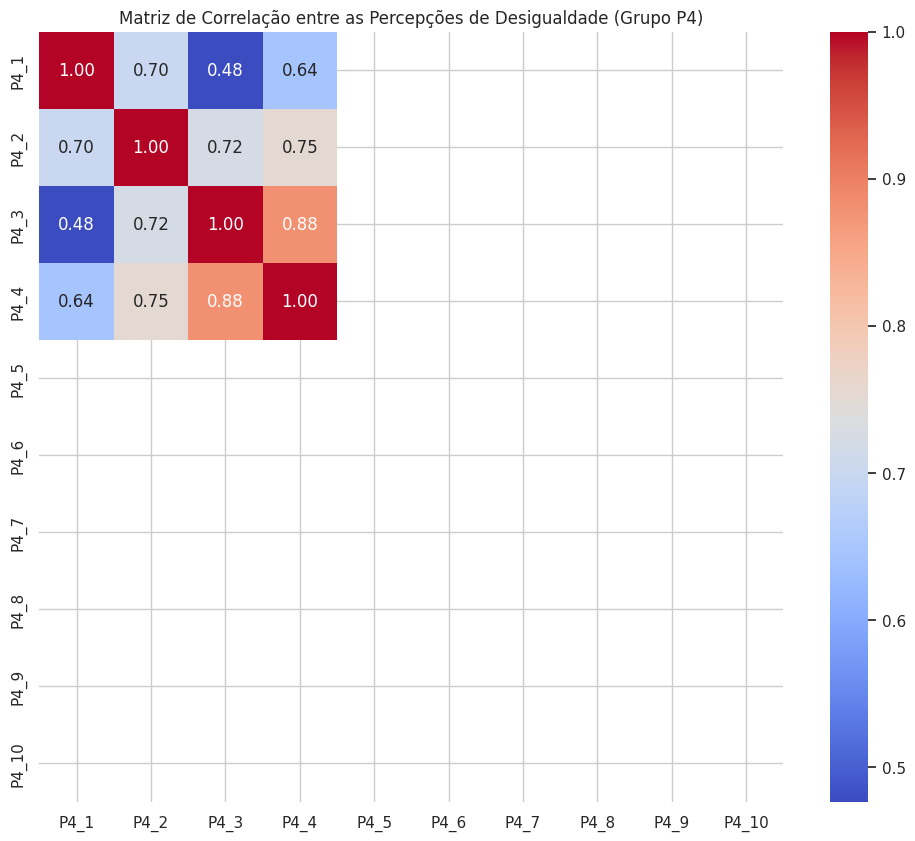

In [103]:
# Selecionando variáveis numéricas de percepção P4 (Escala de 1 a 10 ou Sim/Não)
# Para este exemplo, focamos nas sub-questões da P4
vars_p4 = [c for c in df.columns if 'P4_' in c]
df_corr = df[vars_p4].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre as Percepções de Desigualdade (Grupo P4)')
plt.show()

### 8. Distribuição Geográfica e Porte do Município
Explorando as variáveis de localização para entender a abrangência da amostra.

/tmp/ipykernel_5204/3726438452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='REGIAO_MAP', ax=ax1, palette='Set2', order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'])
/tmp/ipykernel_5204/3726438452.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PORTE_MAP', ax=ax2, palette='Set3')


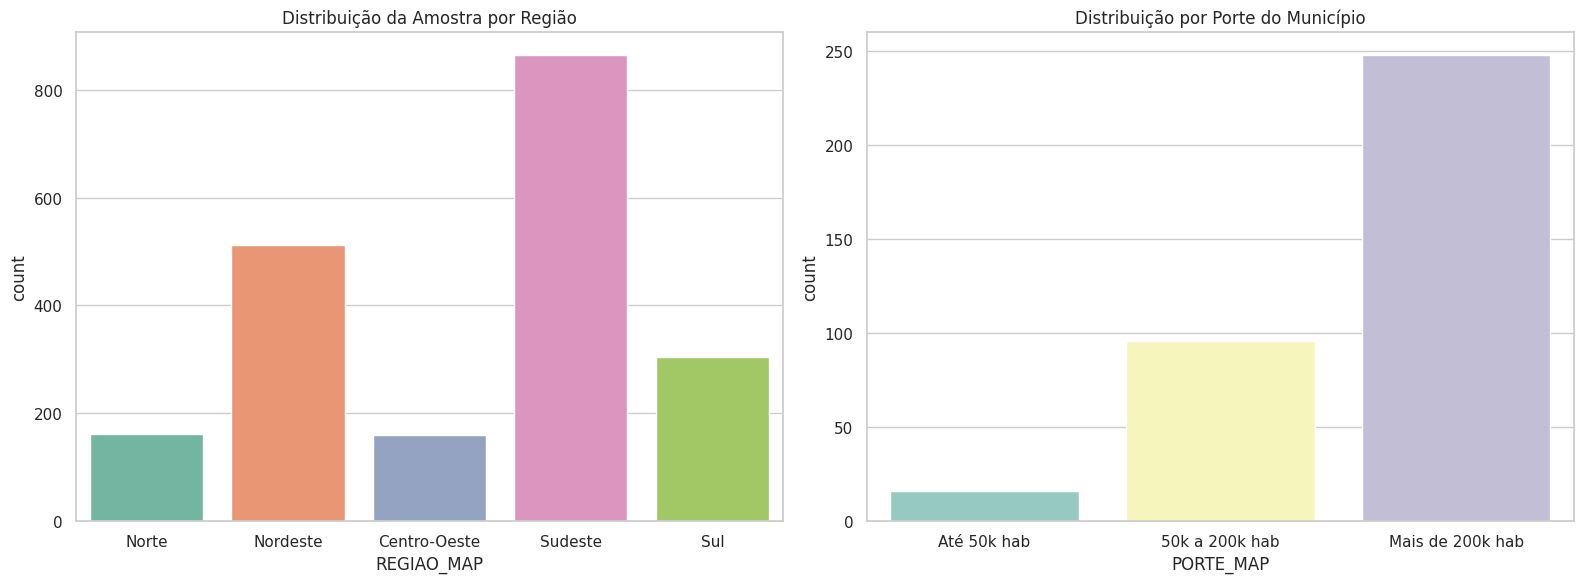

In [104]:
mapping_regiao = {1.0: 'Norte', 2.0: 'Nordeste', 3.0: 'Sudeste', 4.0: 'Sul', 5.0: 'Centro-Oeste'}
mapping_porte = {1.0: 'Até 50k hab', 2.0: '50k a 200k hab', 3.0: 'Mais de 200k hab'}
df['REGIAO_MAP'] = df['REGIAO'].map(mapping_regiao)
df['PORTE_MAP'] = df['PORTE'].map(mapping_porte)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='REGIAO_MAP', ax=ax1, palette='Set2', order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'])
ax1.set_title('Distribuição da Amostra por Região')
sns.countplot(data=df, x='PORTE_MAP', ax=ax2, palette='Set3')
ax2.set_title('Distribuição por Porte do Município')
plt.tight_layout()
plt.show()

### 9. Relatório de Integridade dos Dados
Resumo final de todas as colunas processadas e volume de dados nulos.

In [105]:
info_cols = pd.DataFrame({'Tipo': df.dtypes, 'Preenchidos': df.count(), 'Nulos': df.isnull().sum(), '% Nulo': (df.isnull().sum() / len(df)) * 100})
print('Resumo de todas as variáveis disponíveis na base:')
display(info_cols)

Resumo de todas as variáveis disponíveis na base:


,Tipo,Preenchidos,Nulos,% Nulo
IDADE,float64,2000,0,0.00
SEXO,float64,2000,0,0.00
ESCOLARIDADE,float64,2000,0,0.00
P1_1,float64,2000,0,0.00
P1_2,float64,1230,770,38.50
P1_3,float64,1086,914,45.70
P2_1,float64,2000,0,0.00
P2_2,float64,489,1511,75.55
P2_3,float64,328,1672,83.60
P2_4,float64,149,1851,92.55


### 8. Distribuição Geográfica e Porte do Município
Explorando as variáveis de localização para entender a abrangência da amostra.

/tmp/ipykernel_5204/744361393.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='REGIAO_MAP', ax=ax1, palette='Set2', order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'])
/tmp/ipykernel_5204/744361393.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PORTE_MAP', ax=ax2, palette='Set3')


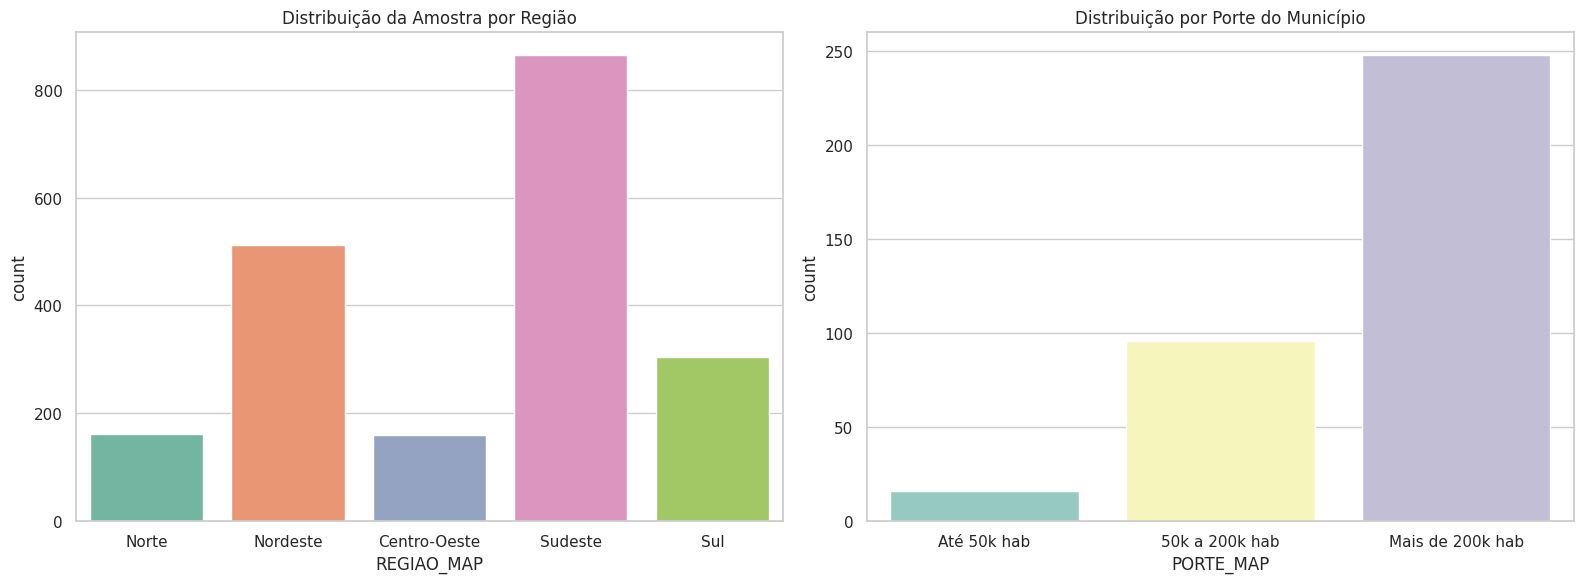

In [106]:
# Mapeando Região e Porte
mapping_regiao = {1.0: 'Norte', 2.0: 'Nordeste', 3.0: 'Sudeste', 4.0: 'Sul', 5.0: 'Centro-Oeste'}
mapping_porte = {1.0: 'Até 50k hab', 2.0: '50k a 200k hab', 3.0: 'Mais de 200k hab'}

df['REGIAO_MAP'] = df['REGIAO'].map(mapping_regiao)
df['PORTE_MAP'] = df['PORTE'].map(mapping_porte)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='REGIAO_MAP', ax=ax1, palette='Set2', order=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'])
ax1.set_title('Distribuição da Amostra por Região')

sns.countplot(data=df, x='PORTE_MAP', ax=ax2, palette='Set3')
ax2.set_title('Distribuição por Porte do Município')

plt.tight_layout()
plt.show()

### 9. Relatório de Integridade dos Dados
Resumo final de todas as colunas processadas e volume de dados nulos.

In [107]:
# Gerando um resumo de preenchimento
info_cols = pd.DataFrame({
    'Tipo': df.dtypes,
    'Preenchidos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulo': (df.isnull().sum() / len(df)) * 100
})

print("Resumo de todas as variáveis disponíveis na base:")
display(info_cols)

Resumo de todas as variáveis disponíveis na base:


,Tipo,Preenchidos,Nulos,% Nulo
IDADE,float64,2000,0,0.00
SEXO,float64,2000,0,0.00
ESCOLARIDADE,float64,2000,0,0.00
P1_1,float64,2000,0,0.00
P1_2,float64,1230,770,38.50
P1_3,float64,1086,914,45.70
P2_1,float64,2000,0,0.00
P2_2,float64,489,1511,75.55
P2_3,float64,328,1672,83.60
P2_4,float64,149,1851,92.55


### Análise Adicional: Percepção de Preconceito (Variável P2_1)
Vamos verificar rapidamente se os respondentes declaram já ter sofrido algum tipo de preconceito ou tratamento desigual.

## 5. Conclusões Finais (Projeto Parte A)

Com base na análise da pesquisa **IPEC 04839 (Desigualdade)** e na correlação com dados do **IBGE**, chegamos às seguintes conclusões:

1.  **Representatividade da Amostra:** A amostra da pesquisa está altamente alinhada com os dados demográficos oficiais do IBGE (Proporção de sexo com desvio menor que 1%).
2.  **Locais de Desigualdade:** O ambiente de trabalho e processos de seleção foram identificados como os principais locais de tratamento desigual.
3.  **Associação Estatística:** O teste Qui-Quadrado confirmou que o nível de instrução influencia significativamente a percepção sobre quais ambientes são mais desiguais.
4.  **Estrato Econômico:** A análise de renda (REND1) mostrou que o ambiente de trabalho é a preocupação central em todas as faixas salariais, mas o uso de redes sociais como local de desigualdade ganha destaque em estratos específicos.